# Figure 2: Paired Day-Night Slopegraph

This notebook isolates the minimal code needed to reproduce the paired day-night slopegraph from A_batch_respirometry_final.ipynb.

## Load data from batch_summary.csv which is created by Notebook A. Execute style code for figure

In [27]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them
use_unfiltered = False

# Locate the processed batch summary from common notebook working directories
candidate_paths = [
    Path.cwd() / "../data/processed/batch_summary.csv",
    Path.cwd() / "data/processed/batch_summary.csv",
    Path("/Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv"),
]

data_path = next((p.resolve() for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find data/processed/batch_summary.csv")

agg_df = pd.read_csv(data_path)
analysis_df = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()

pair_trials = [
    ('trial4', 'trial4.5'),
    ('trial5', 'trial5.5'),
    ('trial6', 'trial6.5'),
    ('trial7', 'trial7.5'),
]

paired_rows = []
for t_a, t_b in pair_trials:
    pair_df = analysis_df[analysis_df['trial'].isin([t_a, t_b])]
    if pair_df.empty:
        continue

    for (brick, channel), grp in pair_df.groupby(['brick', 'channel']):
        if len(grp) != 2:
            continue

        envs = set(grp['environment'])
        if envs != {'day', 'night'}:
            continue

        night_row = grp[grp['environment'] == 'night'].iloc[0]
        day_row = grp[grp['environment'] == 'day'].iloc[0]
        paired_rows.append({
            'pair': f'{t_a}_vs_{t_b}',
            'brick': brick,
            'channel': channel,
            'night': float(night_row['RMR']),
            'day': float(day_row['RMR']),
            'diff_night_minus_day': float(night_row['RMR'] - day_row['RMR']),
        })

paired_df = pd.DataFrame(paired_rows)
print(f'Loaded {len(agg_df)} total rows from {data_path}')
print(f'Paired day-night comparisons: {len(paired_df)}')
display(paired_df)

Loaded 71 total rows from /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv
Paired day-night comparisons: 17


,pair,brick,channel,night,day,diff_night_minus_day
0,trial5_vs_trial5.5,box3,Ch2,2.285837,2.245259,0.040578
1,trial5_vs_trial5.5,box3,Ch3,0.920854,0.427888,0.492965
2,trial5_vs_trial5.5,box3,Ch4,0.473624,0.706451,-0.232827
3,trial5_vs_trial5.5,newbox,Ch2,1.871534,0.756193,1.115341
4,trial5_vs_trial5.5,newbox,Ch3,1.876437,1.199553,0.676884
5,trial5_vs_trial5.5,newbox,Ch4,2.681803,2.995435,-0.313632
6,trial6_vs_trial6.5,box3,Ch2,1.954137,0.949858,1.004280
7,trial6_vs_trial6.5,box3,Ch4,2.182509,0.679472,1.503037
8,trial6_vs_trial6.5,newbox,Ch2,3.222056,1.841349,1.380707
9,trial6_vs_trial6.5,newbox,Ch3,1.424907,0.920279,0.504627


In [26]:
# Load shared Figure style + palette
from pathlib import Path
import importlib.util

style_dir_candidates = [
    Path.cwd() / 'notebooks' / 'styles',
    Path.cwd() / 'styles',
    Path.cwd() / '..' / 'notebooks' / 'styles',
]

style_dir = next(
    (
        p.resolve()
        for p in style_dir_candidates
        if (p / 'photeros.mplstyle').exists() and (p / 'figure_style.py').exists()
    ),
    None,
)

if style_dir is None:
    raise FileNotFoundError('Could not find shared style files in notebooks/styles')

style_path = style_dir / 'photeros.mplstyle'
module_path = style_dir / 'figure_style.py'

spec = importlib.util.spec_from_file_location('figure_style_shared', module_path)
figure_style = importlib.util.module_from_spec(spec)
spec.loader.exec_module(figure_style)

figure_style.apply_photeros_style(style_path)
palette = figure_style.get_palette()

LIGHT_BLUE = palette['light_blue']
DARK_BLUE = palette['dark_blue']
LIGHT_ORANGE = palette['light_orange']
DARK_ORANGE = palette['dark_orange']

print(f'Shared style loaded from: {style_path}')

Shared style loaded from: /Users/oakley/Documents/GitHub/signal_respirometry/notebooks/styles/photeros.mplstyle


## Plot the figure

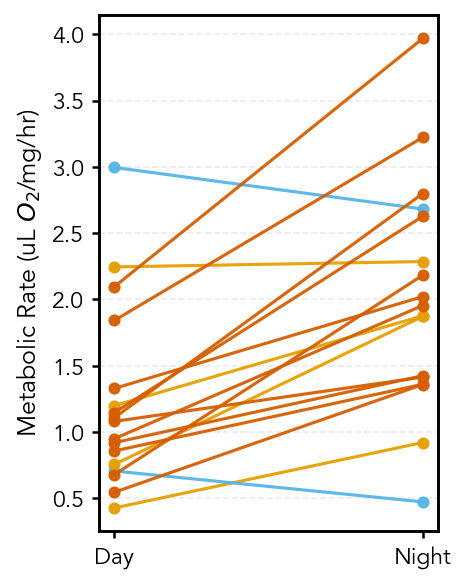

In [25]:
# Slopegraph: Day (left) vs Night (right) for paired comparisons
from matplotlib.lines import Line2D

if paired_df.empty:
    print('No paired data available to plot.')
else:
    plot_df = paired_df.copy()
    plot_df['label'] = plot_df['brick'] + ' | ' + plot_df['channel'] + ' | ' + plot_df['pair']
    plot_df = plot_df.sort_values(['pair', 'brick', 'channel'])

    # Trial start condition used for shade meaning.
    started_in_day = {'trial4_vs_trial4.5', 'trial5_vs_trial5.5'}

    fig, ax = plt.subplots(figsize=(3.2, max(4, 0.1 * len(plot_df))))
    x_day, x_night = 0, 1

    for _, row in plot_df.iterrows():
        y_day = row['day']
        y_night = row['night']
        pair = row['pair']

        # Direction encoded by hue family; start condition encoded by shade.
        if y_night > y_day:
            color = LIGHT_ORANGE if pair in started_in_day else DARK_ORANGE
        else:
            color = LIGHT_BLUE if pair in started_in_day else DARK_BLUE

        ax.plot(
            [x_day, x_night],
            [y_day, y_night],
            marker='o',
            markersize=4.8,
            color=color,
            linewidth=1.5,
            alpha=0.95,
        )

    ax.set_xticks([x_day, x_night])
    ax.set_xticklabels(['Day', 'Night'], fontsize=11, fontweight='bold')
    ax.set_ylabel('Metabolic Rate (uL $O_2$/mg/hr)')
    ax.grid(axis='y', linestyle='--', alpha=0.25)

    plt.tight_layout()
    plt.show()

In [20]:
# Save Figure 2 to files
from pathlib import Path

figures_dir = Path.cwd() / "../figures"
figures_dir.mkdir(parents=True, exist_ok=True)

if 'fig' in locals():
    png_path = (figures_dir / 'Figure2_SlopeGraph.png').resolve()
    pdf_path = (figures_dir / 'Figure2_SlopeGraph.pdf').resolve()

    fig.savefig(png_path, dpi=600, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')

    print(f"Saved PNG: {png_path}")
    print(f"Saved PDF: {pdf_path}")
else:
    print("No figure object found. Run the plotting cell first.")

Saved PNG: /Users/oakley/Documents/GitHub/signal_respirometry/figures/Figure2_SlopeGraph.png
Saved PDF: /Users/oakley/Documents/GitHub/signal_respirometry/figures/Figure2_SlopeGraph.pdf


## Statistical tests associated with the figure

In [21]:
# Statistical tests for paired day-night comparisons
from scipy import stats
import numpy as np

if paired_df.empty:
    print('No paired data available for statistical testing.')
else:
    stats_df = paired_df.copy()

    print('Paired statistical tests (night vs day)')
    print('=' * 60)

    # Overall paired tests across all matched pairs
    t_stat, p_t = stats.ttest_rel(stats_df['night'], stats_df['day'])

    try:
        w_stat, p_w = stats.wilcoxon(stats_df['night'], stats_df['day'], alternative='two-sided')
    except ValueError:
        w_stat, p_w = np.nan, np.nan

    print('\nOverall:')
    print(f"  n pairs = {len(stats_df)}")
    print(f"  mean night = {stats_df['night'].mean():.3f}")
    print(f"  mean day = {stats_df['day'].mean():.3f}")
    print(f"  mean diff (night - day) = {stats_df['diff_night_minus_day'].mean():.3f}")
    print(f"  Paired t-test: t = {t_stat:.3f}, p = {p_t:.4f}")
    print(f"  Wilcoxon signed-rank: W = {w_stat:.3f}, p = {p_w:.4f}")

    # Caption-ready sentence that adapts to full vs subsetted analyses
    sig_text = 'significantly' if (not np.isnan(p_w) and p_w < 0.05) else 'not significantly'
    n_unique_pairs = stats_df['pair'].nunique()

    if n_unique_pairs == 1:
        pair_label = stats_df['pair'].iloc[0]
        caption_sentence = (
            f"Within {pair_label} (n={len(stats_df)} paired comparisons), nighttime metabolic rate was "
            f"{sig_text} higher than daytime metabolic rate "
            f"(Wilcoxon signed-rank: W={w_stat:.3f}, p={p_w:.4f}; paired t-test: t={t_stat:.3f}, p={p_t:.4f})."
        )
    else:
        caption_sentence = (
            f"Across all paired comparisons (n={len(stats_df)}), nighttime metabolic rate was "
            f"{sig_text} higher than daytime metabolic rate "
            f"(Wilcoxon signed-rank: W={w_stat:.3f}, p={p_w:.4f}; paired t-test: t={t_stat:.3f}, p={p_t:.4f})."
        )

    print('\nCaption-ready sentence:')
    print(caption_sentence)

    # By trial-pair block
    print('\nBy trial pair:')
    print('-' * 60)
    summary_rows = []

    for pair_name, sub in stats_df.groupby('pair'):
        if len(sub) < 2:
            summary_rows.append({
                'pair': pair_name,
                'n': len(sub),
                'mean_night': sub['night'].mean(),
                'mean_day': sub['day'].mean(),
                'mean_diff_night_minus_day': sub['diff_night_minus_day'].mean(),
                't_stat': np.nan,
                'p_t': np.nan,
                'w_stat': np.nan,
                'p_w': np.nan,
            })
            continue

        t_sub, p_t_sub = stats.ttest_rel(sub['night'], sub['day'])
        try:
            w_sub, p_w_sub = stats.wilcoxon(sub['night'], sub['day'], alternative='two-sided')
        except ValueError:
            w_sub, p_w_sub = np.nan, np.nan

        summary_rows.append({
            'pair': pair_name,
            'n': len(sub),
            'mean_night': sub['night'].mean(),
            'mean_day': sub['day'].mean(),
            'mean_diff_night_minus_day': sub['diff_night_minus_day'].mean(),
            't_stat': t_sub,
            'p_t': p_t_sub,
            'w_stat': w_sub,
            'p_w': p_w_sub,
        })

    stats_summary_df = pd.DataFrame(summary_rows).sort_values('pair').reset_index(drop=True)
    display(stats_summary_df)

Paired statistical tests (night vs day)

Overall:
  n pairs = 17
  mean night = 2.026
  mean day = 1.229
  mean diff (night - day) = 0.797
  Paired t-test: t = 5.053, p = 0.0001
  Wilcoxon signed-rank: W = 5.000, p = 0.0002

Caption-ready sentence:
Across all paired comparisons (n=17), nighttime metabolic rate was significantly higher than daytime metabolic rate (Wilcoxon signed-rank: W=5.000, p=0.0002; paired t-test: t=5.053, p=0.0001).

By trial pair:
------------------------------------------------------------


,pair,n,mean_night,mean_day,mean_diff_night_minus_day,t_stat,p_t,w_stat,p_w
0,trial5_vs_trial5.5,6,1.685015,1.388463,0.296551,1.295600,0.251699,5.0,0.31250
1,trial6_vs_trial6.5,5,2.160962,1.144031,1.016931,5.298143,0.006095,0.0,0.06250
2,trial7_vs_trial7.5,6,2.254375,1.139289,1.115085,4.201854,0.008474,0.0,0.03125
